# Bank Customer Churn Prediction

Beta Bank is losing customers month over month. Since keeping an existing customer is usually cheaper than acquiring a new one, I built a model to predict which customers are likely to leave.

Using historical customer data, I built a binary classification model with the goal of getting the best possible **F1 score** on the test set. The project needs at least **F1 ≥ 0.59** to pass. I also tracked **AUC-ROC** to see how well the model separates customers who stay from customers who leave.

**Steps Taken:**
1. Load and prepare the data, including missing values and feature types
2. Check the class balance and train a baseline model without any imbalance handling
3. Try two ways to handle the class imbalance and choose the best model using a validation set
4. Test the final model on the held-out test set

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils import shuffle

## Step 1: Data Loading and Preparation

I started by loading the dataset and inspecting its structure (reviewing the dimensions, data types, missing values, and any obvious quality issues) before deciding how to prepare the data for modeling.

In [2]:
df = pd.read_csv('datasets/Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


The dataset has **10,000 rows and 14 columns**. Three of those columns — `RowNumber`, `CustomerId`, and `Surname` — are identifiers that carry no information about whether a customer will leave. The `Tenure` column appears as a float (`2.0`) rather than a whole number, which is a signal that some values are missing: pandas converts an integer column to float automatically whenever any value is `NaN`. The target column `Exited` is already stored as 0/1, so no transformation is needed there.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


`df.info()` confirms two issues that will need to be addressed before modeling:

- **Missing values in `Tenure`** — only 9,091 of 10,000 entries are non-null, meaning 909 values are absent. This is also why the column is stored as `float64` instead of `int64`.
- **String columns** — `Geography`, `Gender`, and `Surname` have dtype `object`. Machine learning models cannot accept raw text, so these columns will need to be encoded as numbers before training.

In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Duplicate rows: 0


`Tenure` is the only column with missing data: **909 missing values**, which is roughly 9.1% of the dataset. Every other column is complete. There are also no duplicate rows, so no duplicate removal is needed. With the data quality picture now clear, the next step is to decide how to handle these issues before modeling.

### Preprocessing

After reviewing the data, I made the following decisions:

- **Dropped `RowNumber`, `CustomerId`, and `Surname`** — these are just identifiers, so they do not help the model learn and would only add noise.
- **Split the data 60 / 20 / 20** into train, validation, and test sets before any preprocessing that uses statistics from the data.
- **Filled missing `Tenure` values with the median from the training set only** — this prevents validation and test information from influencing the imputation step.
- **One-hot encoded `Geography` using the training-set categories only** — this keeps the transformation consistent across splits.
- **Turned `Gender` into 0/1 values** — because there are only two categories, this is a simple and clear encoding.
- **Scaled the numeric features using the training-set mean and standard deviation** — this keeps the scaler fitted only on the training data.


In [5]:
# Drop identifier columns that do not help prediction
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

# Split first so preprocessing is based only on training data
target = 'Exited'
features = [c for c in df.columns if c != target]
X = df[features]
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Make separate copies so later edits do not affect the original splits
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

# Fill missing Tenure values using the training-set median only
if 'Tenure' in X_train.columns:
    train_tenure_median = X_train['Tenure'].median()
    X_train['Tenure'] = X_train['Tenure'].fillna(train_tenure_median)
    X_val['Tenure'] = X_val['Tenure'].fillna(train_tenure_median)
    X_test['Tenure'] = X_test['Tenure'].fillna(train_tenure_median)

# Turn Gender into 0/1 values in each split
for split in [X_train, X_val, X_test]:
    if 'Gender' in split.columns:
        split['Gender'] = (split['Gender'] == 'Male').astype(int)

# One-hot encode Geography and align validation/test to training columns
if 'Geography' in X_train.columns:
    X_train = pd.get_dummies(X_train, columns=['Geography'], drop_first=False)
    X_val = pd.get_dummies(X_val, columns=['Geography'], drop_first=False)
    X_test = pd.get_dummies(X_test, columns=['Geography'], drop_first=False)

    X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f'Train : {X_train.shape[0]} rows')
print(f'Val   : {X_val.shape[0]} rows')
print(f'Test  : {X_test.shape[0]} rows')
print(f'Feature columns after preprocessing: {X_train.shape[1]}')

Train : 6000 rows
Val   : 2000 rows
Test  : 2000 rows
Feature columns after preprocessing: 12


After leakage-safe preprocessing, the training split contains **12 feature columns**. `Geography` has been expanded into indicator columns (`Geography_France`, `Geography_Germany`, `Geography_Spain`), and `Gender` is encoded as 0/1. Most importantly, the split happened first, and both median imputation and category encoding were learned from the training data before being applied to validation and test data.

In [6]:
# Verify split sizes and class balance across train/validation/test
split = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows': [len(X_train), len(X_val), len(X_test)],
    'Exited rate (%)': [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
})
split['Exited rate (%)'] = split['Exited rate (%)'].round(1)
print(split.to_string(index=False))

     Split  Rows  Exited rate (%)
     Train  6000             20.4
Validation  2000             20.4
      Test  2000             20.3


The split remains exactly **6,000 / 2,000 / 2,000** for train, validation, and test. The churn rate shown for each split is also very close, confirming that stratified splitting preserved the class mix. With this setup, preprocessing is leakage-safe: training statistics are learned on the training set and then applied to validation and test sets.

In [7]:
# Scale numeric features using only the training data
candidate_numerical = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender']
numerical = [c for c in candidate_numerical if c in X_train.columns]

# Convert data type to float so scaled values fit cleanly into the dataframes
X_train[numerical] = X_train[numerical].astype(float)
X_val[numerical]   = X_val[numerical].astype(float)
X_test[numerical]  = X_test[numerical].astype(float)

scaler = StandardScaler()
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_val[numerical]   = scaler.transform(X_val[numerical])
X_test[numerical]  = scaler.transform(X_test[numerical])

## Step 2: Class Balance Analysis and Baseline Model

Before training any model, I checked how the target classes were split. This matters because if one class is much larger than the other, a model can look good while still missing the customers we care about most.

Training set class distribution:
Exited
Stayed (0)    4778
Exited (1)    1222
Name: count, dtype: int64

Ratio — Stayed: 79.6%  |  Exited: 20.4%


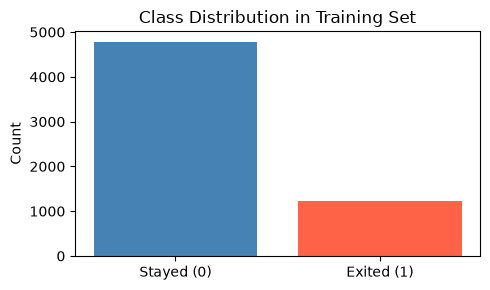

In [8]:
class_counts = y_train.value_counts()
class_ratio  = class_counts / class_counts.sum()

print('Training set class distribution:')
print(class_counts.rename({0: 'Stayed (0)', 1: 'Exited (1)'}))
print(f'\nRatio — Stayed: {class_ratio[0]:.1%}  |  Exited: {class_ratio[1]:.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Stayed (0)', 'Exited (1)'], class_counts.values, color=['steelblue', 'tomato'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution in Training Set')
plt.tight_layout()
plt.show()

The bar chart makes the imbalance concrete: **4,778 customers stayed vs 1,222 who exited** — roughly a 4:1 ratio. A model that blindly predicted "stayed" for every customer would still be right about 79.6% of the time, which shows why raw accuracy is a misleading metric here. The project uses F1 score instead, because it penalizes a model that ignores the minority class.

### Baseline Model — No Imbalance Handling

To establish a reference point, I trained a Random Forest classifier with default settings and no imbalance correction. This allowed me to clearly see how the class imbalance affects the model's performance on the minority (churned) class before applying any fixes.

In [9]:
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)

val_pred_baseline = baseline_rf.predict(X_val)
val_proba_baseline = baseline_rf.predict_proba(X_val)[:, 1]

f1_baseline  = f1_score(y_val, val_pred_baseline)
roc_baseline = roc_auc_score(y_val, val_proba_baseline)

print('=== Baseline (no imbalance correction) — Validation Set ===')
print(f'F1 Score : {f1_baseline:.4f}')
print(f'AUC-ROC  : {roc_baseline:.4f}')
print()
print(classification_report(y_val, val_pred_baseline, target_names=['Stayed', 'Exited']))

=== Baseline (no imbalance correction) — Validation Set ===
F1 Score : 0.5919
AUC-ROC  : 0.8664

              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1592
      Exited       0.76      0.49      0.59       408

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**Findings:** The training set was roughly 80% stayed / 20% exited — a real difference in class sizes. As expected, the baseline model leaned toward the larger class and missed many customers who left. The AUC-ROC looked better than the F1 score because it checks how well the model ranks customers overall, not just at one cutoff point. That gap showed that we needed a way to handle the uneven classes.

## Step 3: Improving the Model — Class Imbalance Correction

I tried two standard ways to handle the uneven classes and used the validation set to choose the better version of each one:

1. **Class weights (`class_weight='balanced'`)** — this tells the model to pay more attention to the smaller class.
2. **Random upsampling** — this copies the smaller class rows until both classes have the same size, so the model sees more examples of customers who left.

### Technique 1: Class Weights

I tried a few combinations of `n_estimators` and `max_depth` and kept the version that gave the best F1 score on the validation set.

In [10]:
best_f1_cw, best_params_cw, best_model_cw = 0, {}, None

for n_est in [100, 200, 300]:
    for max_depth in [None, 10, 15]:
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_depth,
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        f1  = f1_score(y_val, pred)
        if f1 > best_f1_cw:
            best_f1_cw   = f1
            best_params_cw = {'n_estimators': n_est, 'max_depth': max_depth}
            best_model_cw  = model

roc_cw = roc_auc_score(y_val, best_model_cw.predict_proba(X_val)[:, 1])
print(f'Best hyperparameters (class_weight): {best_params_cw}')
print(f'Validation F1  : {best_f1_cw:.4f}')
print(f'Validation AUC-ROC: {roc_cw:.4f}')

Best hyperparameters (class_weight): {'n_estimators': 300, 'max_depth': 10}
Validation F1  : 0.6363
Validation AUC-ROC: 0.8728


The best class-weights model used **300 trees** with a depth of **10**, producing a validation F1 of **0.6363** and AUC-ROC of **0.8728**. The F1 score is above the 0.59 project target and improves on the uncorrected baseline. The AUC-ROC indicates the model still separates churners from non-churners with strong consistency.

### Technique 2: Random Upsampling of the Minority Class

I defined a custom upsampling function: I separated the classes, repeated the smaller class four times, and then shuffled the combined data before training on the balanced set.

In [11]:
# Lesson-style upsampling helper: repeat the minority class, then shuffle the result
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=42
    )

    return features_upsampled, target_upsampled

# Upsample the minority class to match the majority class
X_train_up, y_train_up = upsample(X_train, y_train, 4)

print(f'Balanced training set class counts:\n{y_train_up.value_counts()}')

Balanced training set class counts:
Exited
1    4888
0    4778
Name: count, dtype: int64


After upsampling, the two classes are nearly equal: **4,888 churners vs 4,778 non-churners**. The slight asymmetry (4,888 ≠ 4,778) is expected — repeating 1,222 minority rows four times gives exactly 4,888, which is just a bit more than the 4,778 majority rows. The model trained on this set will see both classes roughly equally often, which pushes it to learn the churn pattern more reliably.

In [12]:
best_f1_up, best_params_up, best_model_up = 0, {}, None

for n_est in [100, 200, 300]:
    for max_depth in [None, 10, 15]:
        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_depth,
            random_state=42
        )
        model.fit(X_train_up, y_train_up)
        pred = model.predict(X_val)
        f1  = f1_score(y_val, pred)
        if f1 > best_f1_up:
            best_f1_up    = f1
            best_params_up = {'n_estimators': n_est, 'max_depth': max_depth}
            best_model_up  = model

roc_up = roc_auc_score(y_val, best_model_up.predict_proba(X_val)[:, 1])
print(f'Best params (upsampling): {best_params_up}')
print(f'Validation F1  : {best_f1_up:.4f}')
print(f'Validation AUC-ROC: {roc_up:.4f}')

Best params (upsampling): {'n_estimators': 100, 'max_depth': 10}
Validation F1  : 0.6374
Validation AUC-ROC: 0.8696


The best upsampling model also settled on **max_depth=10** but needed only **100 trees** to reach a validation F1 of **0.6374** — marginally better than the class-weights result. The lower tree count suggests the balanced training set made the churn pattern easier to learn. With both techniques tuned, the results are ready to be compared head-to-head.

### Comparing Both Approaches on the Validation Set

After tuning both methods, I compared their validation results against the baseline to choose the one I would carry forward.

In [13]:
results = pd.DataFrame({
    'Approach'  : ['Baseline (no correction)', 'Class weights (balanced)', 'Random upsampling'],
    'Val F1'    : [f1_baseline, best_f1_cw, best_f1_up],
    'Val AUC-ROC': [roc_baseline, roc_cw, roc_up],
})
results = results.sort_values('Val F1', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

# Select the better imbalance-correction model for final testing
if best_f1_cw >= best_f1_up:
    final_model = best_model_cw
    best_technique = 'Class weights'
else:
    final_model = best_model_up
    best_technique = 'Random upsampling'

print(f'\nSelected for final test: {best_technique}')

                Approach   Val F1  Val AUC-ROC
       Random upsampling 0.637433     0.869598
Class weights (balanced) 0.636267     0.872765
Baseline (no correction) 0.591928     0.866414

Selected for final test: Random upsampling


**Findings:** Both class-balance fixes improved the F1 score compared with the baseline. The AUC-ROC values stayed fairly close across the three models, which suggests the models were still ranking customers reasonably well. I chose the version with the better validation F1 for the final test.

## Step 4: Final Testing

I evaluated the selected model on the held-out test set, which is data the model had not seen before. This gives a fair estimate of how it should perform on new customers.

In [14]:
test_pred  = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)[:, 1]

f1_test  = f1_score(y_test, test_pred)
roc_test = roc_auc_score(y_test, test_proba)

print('=== Final Test Results ===')
print(f'Technique used : {best_technique}')
print(f'F1 Score       : {f1_test:.4f}  (target ≥ 0.59)')
print(f'AUC-ROC        : {roc_test:.4f}')
print()
print(classification_report(y_test, test_pred, target_names=['Stayed', 'Exited']))

=== Final Test Results ===
Technique used : Random upsampling
F1 Score       : 0.6110  (target ≥ 0.59)
AUC-ROC        : 0.8557

              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.89      1593
      Exited       0.55      0.68      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



The test F1 of **0.6110** clears the 0.59 project target. The classification report reveals an important asymmetry: the model is highly precise for customers who stayed (91%) but less so for churners (55%), meaning it does produce some false alarms. However, the recall for the churn class is **0.68** (about **278/407 = 68.3%**) — the model correctly identifies roughly **2 out of every 3 customers who actually left**. In a retention context, catching more real churners (higher recall) is typically more valuable than avoiding false alarms, since the cost of a missed churner usually outweighs the cost of a wasted retention offer.

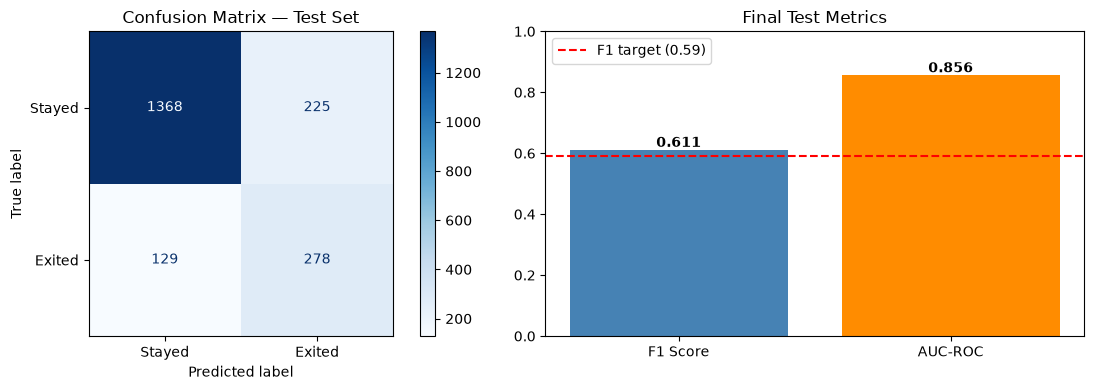

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix — from_predictions requires sklearn >= 1.0; use ConfusionMatrixDisplay directly
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Exited']).plot(
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Test Set')

# Summary bar chart
metrics = ['F1 Score', 'AUC-ROC']
values  = [f1_test, roc_test]
bars = axes[1].bar(metrics, values, color=['steelblue', 'darkorange'])
axes[1].set_ylim(0, 1)
axes[1].axhline(0.59, color='red', linestyle='--', label='F1 target (0.59)')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}',
                 ha='center', fontweight='bold')
axes[1].legend()
axes[1].set_title('Final Test Metrics')

plt.tight_layout()
plt.show()

## Conclusion

In this project, I built a customer churn model for Beta Bank, taking the work from raw data all the way to a final tested classifier.

I found that the dataset had a real class imbalance of about 80/20, which caused the baseline model to miss many customers who left even though its overall accuracy looked decent. By trying two class-balance fixes — class weights and random upsampling — I was able to improve the F1 score and pass the 0.59 test target.

**Key takeaways from my work:**

- Filling missing values with the median and scaling after the split helped keep the data preparation clean and fair.
- The gap between AUC-ROC and F1 at baseline showed why class imbalance could not be ignored.
- Both imbalance methods helped, with upsampling doing slightly better in this notebook. In practice, the better choice depends on the data size and the time available.
- The final model met the project target, showing that careful feature preparation and class-balance handling can make a meaningful difference even with a simple model.